In [1]:
#imports and libraries
import numpy as np
import pandas as pd
import joblib as jl
import sys
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor,RandomForestClassifier
from sklearn.model_selection import cross_val_score,TimeSeriesSplit
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    classification_report,
    confusion_matrix,
    mean_absolute_error,
    root_mean_squared_error
)
from matplotlib import pyplot as plt
import seaborn as sb

sys.path.append("..")

In [ ]:
# 
train  = pd.read_csv("../data/processed/train.csv")
test   = pd.read_csv("../data/processed/test.csv")
val    = pd.read_csv("../data/processed/val.csv")
scaler = jl.load("../models/scaler.pkl")

features = [
    "T2M_mean", "RH2M_mean", "PRECTOTCORR_sum", "WS10M_mean",
    "T2M_lag1", "PRECTOTCORR_lag1", "PRECTOTCORR_lag2",
    "t1_cases", "t2_cases",
    "waterProxy",
    "month_sin", "week_cos",
    "isOutbreak"
]
target = "cases"

xTrain = train[features]
xTest  = test[features]
xVal   = val[features].copy()
yTrain = train[target]
yTest  = test[target]
yVal   = val["cases"].copy()

# wrap in DataFrame to preserve feature names — fixes the warning
xTrainScaled = pd.DataFrame(scaler.transform(xTrain), columns=features)
xValScaled   = pd.DataFrame(scaler.transform(xVal),   columns=features)
xTestScaled  = pd.DataFrame(scaler.transform(xTest),  columns=features)

In [5]:
# helper function to evaluate the model accuracy for the regressors

def regressorEvaluation(model,xTest,yTest):

    predictions=model.predict(xTest)
    meanSquareError=mean_squared_error(yTest, predictions)
    r2=r2_score(yTest, predictions)
    rootMeanSquareError=root_mean_squared_error(yTest, predictions)
    meanAbsoluteError=mean_absolute_error(yTest, predictions)
    print("The Model Performance metrics are:")
    print(f"R2 Score: {r2}")
    print(f"Mean Squared Error: {meanSquareError}")
    print(f"Root Mean Squared Error: {rootMeanSquareError}")
    print(f"Mean Absolute Error: {meanAbsoluteError}")

    return {
        "R2_Score": r2,
        "MeanSquaredError": meanSquareError,
        "RootMeanSquaredError": rootMeanSquareError,
        "MeanAbsoluteError": meanAbsoluteError
    }

In [ ]:
# Linear Regression as baseline model

linearRegression = LinearRegression()
linearRegression.fit(xTrainScaled, yTrain)

timeCv = TimeSeriesSplit(n_splits=5)
cvScore = cross_val_score(linearRegression, xTrainScaled, yTrain, cv=timeCv, scoring='r2')
print(f"Cross Validation Average R2 Score: {cvScore.mean():.4f}")
print(f"Cross Validation R2 Scores Std: {cvScore.std():.4f}")
print(f"Mean: {cvScore.mean():.4f} ± {cvScore.std():.4f}")

yValLr = val["cases"].copy()
print("\n=== Val 2019 (outbreak) ===")
linearEvaluationsVal = regressorEvaluation(linearRegression, xValScaled, yValLr)

print("\n=== Test 2020 (final) ===")
linearEvaluations = regressorEvaluation(linearRegression, xTestScaled, yTest)

jl.dump(linearRegression, "../models/linear_baseline.pkl")

Cross Validation Average R2 Score: 0.6399
Cross Validation R2 Scores Std: 0.0646
Mean: 0.6399 ± 0.0646

=== Val 2019 (outbreak) ===
The Model Performance metrics are:
R2 Score: 0.6204654728580135
Mean Squared Error: 408.06542216538446
Root Mean Squared Error: 20.200629251718485
Mean Absolute Error: 8.5705148792375

=== Test 2020 (final) ===
The Model Performance metrics are:
R2 Score: 0.42171250081424505
Mean Squared Error: 7.058476371716559
Root Mean Squared Error: 2.6567793231122074
Mean Absolute Error: 1.94540202996665


['../models/linear_baseline.pkl']

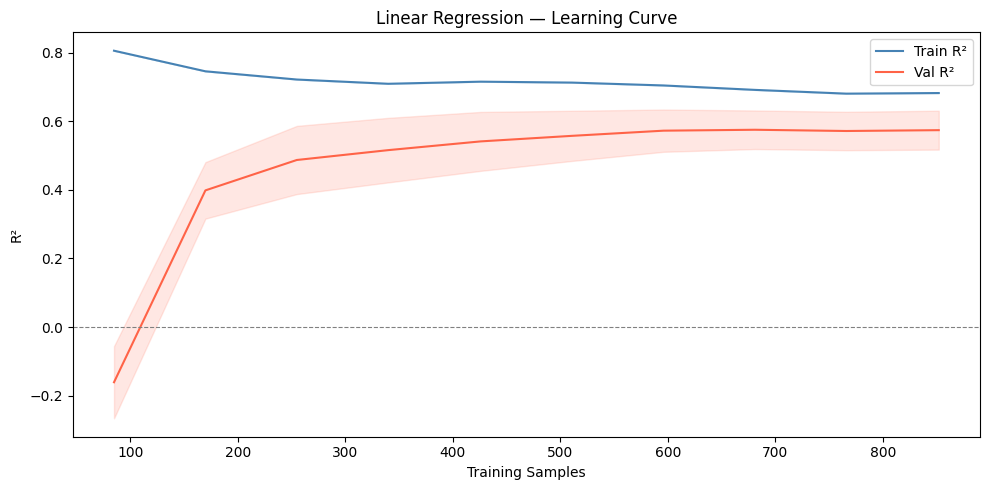

Final train R²: 0.6827 ± 0.0000
Final val   R²: 0.5744 ± 0.0568
Gap:            0.1083


In [50]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt
import numpy as np

trainSizes, trainScores, valScores = learning_curve(
    linearRegression, xTrainScaled, yTrain,
    cv=TimeSeriesSplit(n_splits=5),   # consistent with RF and XGBoost
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

trainMean = trainScores.mean(axis=1)
trainStd  = trainScores.std(axis=1)
valMean   = valScores.mean(axis=1)
valStd    = valScores.std(axis=1)

plt.figure(figsize=(10, 5))
plt.plot(trainSizes, trainMean, label="Train R²", color="steelblue")
plt.fill_between(trainSizes, trainMean - trainStd, trainMean + trainStd,
                 alpha=0.15, color="steelblue")
plt.plot(trainSizes, valMean, label="Val R²", color="tomato")
plt.fill_between(trainSizes, valMean - valStd, valMean + valStd,
                 alpha=0.15, color="tomato")
plt.axhline(y=0, color="gray", linestyle="--", linewidth=0.8)
plt.xlabel("Training Samples")
plt.ylabel("R²")
plt.title("Linear Regression — Learning Curve")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Final train R²: {trainMean[-1]:.4f} ± {trainStd[-1]:.4f}")
print(f"Final val   R²: {valMean[-1]:.4f} ± {valStd[-1]:.4f}")
print(f"Gap:            {trainMean[-1] - valMean[-1]:.4f}")

In [ ]:
# ── Random Forest ─────────────────────────────────────────────────────────────
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, cross_val_score, learning_curve
import matplotlib.pyplot as plt
import numpy as np

featuresRf = [
    "district_encoded", "T2M_mean", "RH2M_mean", "PRECTOTCORR_sum", "WS10M_mean",
    "T2M_lag1", "PRECTOTCORR_lag1", "PRECTOTCORR_lag2",
    "t1_cases", "t2_cases",
    "waterProxy",
    "month_sin", "week_cos", "momentum", "isOutbreak"
]
targetRf = "cases"

xTrainRf = train[featuresRf]
xValRf   = val[featuresRf].copy()
xTestRf  = test[featuresRf].copy()
yTrainRf = train[targetRf]
yValRf   = val[targetRf].copy()
yTestRf  = test[targetRf].copy()

gridParameters = {
    'max_depth':         [7, 8, 9],
    'min_samples_leaf':  [6, 8, 10],
    'min_samples_split': [10, 15, 20],
    'max_features':      [0.6, 0.7, 0.8],
    'max_samples':       [0.8, 0.9],
}

tCsv = TimeSeriesSplit(n_splits=5)

gridSearch = GridSearchCV(
    estimator=RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    param_grid=gridParameters,
    cv=tCsv,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
gridSearch.fit(xTrainRf, yTrainRf)

print(f"Best params: {gridSearch.best_params_}")
print(f"Best CV R²:  {gridSearch.best_score_:.4f}")

rfModel = gridSearch.best_estimator_

scores = cross_val_score(rfModel, xTrainRf, yTrainRf, cv=tCsv, scoring='r2')
print(f"CV Mean: {scores.mean():.4f} ± {scores.std():.4f}")

print("\n=== Val 2019 (outbreak) ===")
regressorEvaluation(rfModel, xValRf, yValRf)

print("\n=== Test 2020 (final) ===")
regressorEvaluation(rfModel, xTestRf, yTestRf)

# feature importance
importance = pd.Series(rfModel.feature_importances_, index=featuresRf).sort_values(ascending=False)
print("\nFeature importances:")
print(importance.round(4))

jl.dump(rfModel, "../models/rf_regressor.pkl")
print("Saved → ../models/rf_regressor.pkl")

trainSizes, trainScores, valScores = learning_curve(
    rfModel, xTrainRf, yTrainRf,
    cv=TimeSeriesSplit(n_splits=5),
    scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=-1
)

trainMean = trainScores.mean(axis=1)
trainStd  = trainScores.std(axis=1)
valMean   = valScores.mean(axis=1)
valStd    = valScores.std(axis=1)

plt.figure(figsize=(10, 5))
plt.plot(trainSizes, trainMean, label="Train RMSE", color="steelblue")
plt.fill_between(trainSizes, trainMean - trainStd, trainMean + trainStd,
                 alpha=0.15, color="steelblue")
plt.plot(trainSizes, valMean, label="Val RMSE", color="tomato")
plt.fill_between(trainSizes, valMean - valStd, valMean + valStd,
                 alpha=0.15, color="tomato")
plt.axhline(y=0, color="gray", linestyle="--", linewidth=0.8)
plt.xlabel("Training Samples")
plt.ylabel("RMSE")
plt.title("Random Forest — Learning Curve")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Final train R2: {trainMean[-1]:.4f} ± {trainStd[-1]:.4f}")
print(f"Final val   R2: {valMean[-1]:.4f} ± {valStd[-1]:.4f}")
print(f"Gap:            {trainMean[-1] - valMean[-1]:.4f}")

Fitting 5 folds for each of 162 candidates, totalling 810 fits
Best params: {'max_depth': 9, 'max_features': 0.8, 'max_samples': 0.9, 'min_samples_leaf': 6, 'min_samples_split': 10}
Best CV R²:  0.7420
CV Mean: 0.7420 ± 0.1781

=== Val 2019 (outbreak) ===
The Model Performance metrics are:
R2 Score: 0.19697096298780759
Mean Squared Error: 863.3954477529046
Root Mean Squared Error: 29.383591471311068
Mean Absolute Error: 11.076047176417362

=== Test 2020 (final) ===
The Model Performance metrics are:
R2 Score: 0.8915666304345534
Mean Squared Error: 1.3235188000103457
Root Mean Squared Error: 1.1504428712501746
Mean Absolute Error: 0.7154199687976687

Feature importances:
momentum            0.3422
t1_cases            0.3079
month_sin           0.1020
t2_cases            0.0961
week_cos            0.0925
T2M_lag1            0.0093
T2M_mean            0.0092
isOutbreak          0.0082
PRECTOTCORR_lag2    0.0082
WS10M_mean          0.0051
RH2M_mean           0.0048
district_encoded    0.00

InvalidParameterError: The 'scoring' parameter of learning_curve must be a str among {'jaccard', 'jaccard_macro', 'adjusted_rand_score', 'neg_mean_squared_error', 'neg_root_mean_squared_log_error', 'precision_samples', 'v_measure_score', 'homogeneity_score', 'recall_micro', 'rand_score', 'mutual_info_score', 'top_k_accuracy', 'adjusted_mutual_info_score', 'precision_macro', 'f1_macro', 'neg_mean_absolute_error', 'neg_mean_squared_log_error', 'positive_likelihood_ratio', 'neg_log_loss', 'roc_auc', 'f1_samples', 'neg_mean_gamma_deviance', 'neg_root_mean_squared_error', 'precision_weighted', 'neg_max_error', 'neg_negative_likelihood_ratio', 'recall_weighted', 'r2', 'recall_samples', 'neg_mean_poisson_deviance', 'roc_auc_ovo', 'explained_variance', 'neg_median_absolute_error', 'f1_weighted', 'normalized_mutual_info_score', 'roc_auc_ovr', 'balanced_accuracy', 'd2_brier_score', 'f1_micro', 'precision', 'matthews_corrcoef', 'recall', 'jaccard_samples', 'roc_auc_ovr_weighted', 'recall_macro', 

[0]	validation_0-rmse:3.99240	validation_1-rmse:3.52179
[100]	validation_0-rmse:1.65357	validation_1-rmse:1.44307
[200]	validation_0-rmse:1.30658	validation_1-rmse:1.20981
[300]	validation_0-rmse:1.14496	validation_1-rmse:1.17660
[400]	validation_0-rmse:1.02630	validation_1-rmse:1.14787
[500]	validation_0-rmse:0.94500	validation_1-rmse:1.12558
[592]	validation_0-rmse:0.88224	validation_1-rmse:1.14263
Best iteration: 542
Best val RMSE:  1.1247
CV Mean: 0.7132 ± 0.1952

=== Val 2019 (outbreak) ===
The Model Performance metrics are:
R2 Score: 0.21972203254699707
Mean Squared Error: 838.9341430664062
Root Mean Squared Error: 28.964359283447266
Mean Absolute Error: 11.16681957244873

=== Test 2020 (final) ===
The Model Performance metrics are:
R2 Score: 0.8334460258483887
Mean Squared Error: 2.032928466796875
Root Mean Squared Error: 1.4258079528808594
Mean Absolute Error: 0.9305517673492432


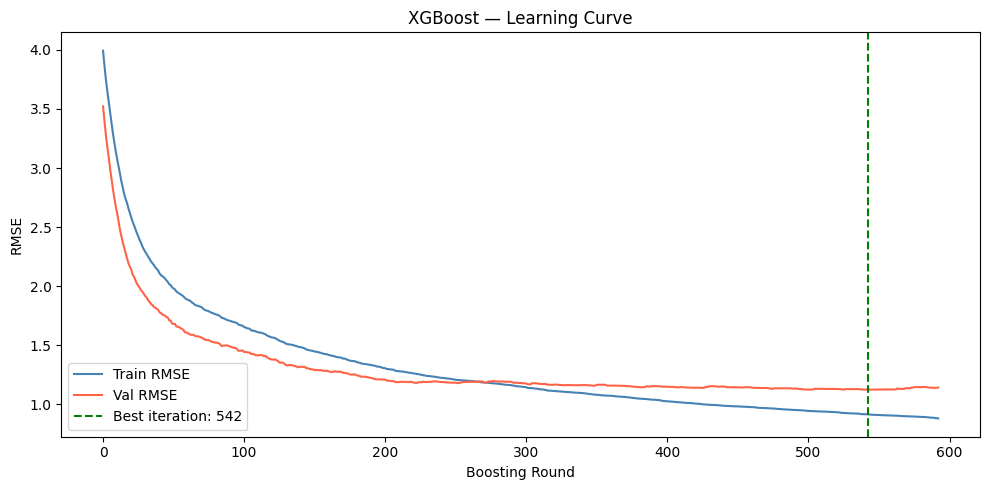

['../models/xgboost_regressor.pkl']

In [ ]:
#XGBoost 
from xgboost import XGBRegressor as xgBoostRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
import matplotlib.pyplot as plt

featuresXg = [
    "district_encoded", "T2M_mean", "RH2M_mean", "PRECTOTCORR_sum", "WS10M_mean",
    "T2M_lag1", "PRECTOTCORR_lag1", "PRECTOTCORR_lag2",
    "t1_cases", "t2_cases",
    "waterProxy",
    "month_sin", "week_cos", "momentum", "isOutbreak"
]
targetXg = "cases"

xTrainXg = train[featuresXg]
xValXg   = val[featuresXg].copy()
xTestXg  = test[featuresXg].copy()
yTrainXg = train[targetXg]
yValXg   = val[targetXg].copy()
yTestXg  = test[targetXg].copy()


tCsv   = TimeSeriesSplit(n_splits=5)
splits = list(tCsv.split(xTrainXg))
trainIdx, valIdx = splits[-1]

xEarlySplit = xTrainXg.iloc[trainIdx]
yEarlySplit = yTrainXg.iloc[trainIdx]
xValSplit   = xTrainXg.iloc[valIdx]
yValSplit   = yTrainXg.iloc[valIdx]

xgModel = xgBoostRegressor(
    learning_rate=0.05,
    n_estimators=2000,
    max_depth=3,
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_weight=10,
    reg_alpha=0.5,
    reg_lambda=2.0,
    early_stopping_rounds=50,
    eval_metric="rmse",
    random_state=42,
    n_jobs=-1
)

xgModel.fit(
    xEarlySplit, yEarlySplit,
    eval_set=[
        (xEarlySplit, yEarlySplit),
        (xValSplit,   yValSplit)
    ],
    verbose=100
)

print(f"Best iteration: {xgModel.best_iteration}")
print(f"Best val RMSE:  {xgModel.best_score:.4f}")

# CV with fixed n_estimators
xgModelCv = xgBoostRegressor(
    learning_rate=0.05,
    n_estimators=xgModel.best_iteration,
    max_depth=3,
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_weight=10,
    reg_alpha=0.5,
    reg_lambda=2.0,
    random_state=42,
    n_jobs=-1
)
xgScores = cross_val_score(xgModelCv, xTrainXg, yTrainXg, cv=tCsv, scoring='r2')
print(f"CV Mean: {xgScores.mean():.4f} ± {xgScores.std():.4f}")

print("\n=== Val 2019 (outbreak) ===")
regressorEvaluation(xgModel, xValXg, yValXg)

print("\n=== Test 2020 (final) ===")
regressorEvaluation(xgModel, xTestXg, yTestXg)


results = xgModel.evals_result()

plt.figure(figsize=(10, 5))
plt.plot(results["validation_0"]["rmse"], label="Train RMSE", color="steelblue")
plt.plot(results["validation_1"]["rmse"], label="Val RMSE",   color="tomato")
plt.axvline(x=xgModel.best_iteration, color="green", linestyle="--",
            label=f"Best iteration: {xgModel.best_iteration}")
plt.xlabel("Boosting Round")
plt.ylabel("RMSE")
plt.title("XGBoost — Learning Curve")
plt.legend()
plt.tight_layout()
plt.show()

jl.dump(xgModel, "../models/xgboost_regressor.pkl")

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold
import joblib as jl

featuresRf = [
    "district_encoded", "T2M_mean", "RH2M_mean", "PRECTOTCORR_sum", "WS10M_mean",
    "T2M_lag1", "PRECTOTCORR_lag1", "PRECTOTCORR_lag2",
    "t1_cases", "t2_cases",
    "waterProxy",
    "month_sin", "week_cos", "momentum", "isOutbreak"
]

xTrain2019 = val[featuresRf].copy()
yTrain2019 = val["cases"].copy()

print(f"2019 training rows: {len(xTrain2019)}")
print(f"Cases — mean: {yTrain2019.mean():.2f}, max: {yTrain2019.max():.2f}")

rfOutbreak = RandomForestRegressor(
    n_estimators=300,
    max_depth=8,
    min_samples_leaf=5,
    min_samples_split=10,
    max_features=0.7,
    max_samples=0.8,
    random_state=42,
    n_jobs=-1
)

rfOutbreak.fit(xTrain2019, yTrain2019)

print("\n=== Train fit (2019) ===")
regressorEvaluation(rfOutbreak, xTrain2019, yTrain2019)

kf = KFold(n_splits=5, shuffle=False)
cvScores = cross_val_score(rfOutbreak, xTrain2019, yTrain2019, cv=kf, scoring='r2')
print(f"\nCV Mean: {cvScores.mean():.4f} ± {cvScores.std():.4f}")

print("\n=== Test 2020 (how outbreak model handles normal year) ===")
regressorEvaluation(rfOutbreak, test[featuresRf], test["cases"])

importance = pd.Series(rfOutbreak.feature_importances_, index=featuresRf).sort_values(ascending=False)
print("\nFeature importances:")
print(importance.round(4))

jl.dump(rfOutbreak, "../models/rf_regressor_outbreak.pkl")
print("\nSaved → ../models/rf_regressor_outbreak.pkl")

2019 training rows: 1728
Cases — mean: 17.92, max: 356.00

=== Train fit (2019) ===
The Model Performance metrics are:
R2 Score: 0.9413854364859479
Mean Squared Error: 63.02081864729344
Root Mean Squared Error: 7.938565276376672
Mean Absolute Error: 2.5535604363217526

CV Mean: 0.8957 ± 0.0591

=== Test 2020 (how outbreak model handles normal year) ===
The Model Performance metrics are:
R2 Score: -17.91792275836052
Mean Squared Error: 230.90886622979585
Root Mean Squared Error: 15.195685776884037
Mean Absolute Error: 8.071765023172262

Feature importances:
momentum            0.4703
t1_cases            0.1887
month_sin           0.1800
week_cos            0.0583
t2_cases            0.0442
T2M_mean            0.0155
PRECTOTCORR_lag1    0.0109
PRECTOTCORR_lag2    0.0086
PRECTOTCORR_sum     0.0055
waterProxy          0.0046
T2M_lag1            0.0036
district_encoded    0.0027
WS10M_mean          0.0026
RH2M_mean           0.0023
isOutbreak          0.0022
dtype: float64

Saved → ../model

[0]	validation_0-rmse:32.10912	validation_1-rmse:29.61897


[100]	validation_0-rmse:9.76094	validation_1-rmse:8.54816
[200]	validation_0-rmse:7.67812	validation_1-rmse:8.18822
[300]	validation_0-rmse:6.37307	validation_1-rmse:7.90464
[376]	validation_0-rmse:5.61406	validation_1-rmse:7.85379
Best iteration: 326
Best val RMSE:  7.7876
CV Mean: 0.8003 ± 0.1131

=== Val 2019 (outbreak) ===
The Model Performance metrics are:
R2 Score: 0.9614174365997314
Mean Squared Error: 41.48295593261719
Root Mean Squared Error: 6.440726280212402
Mean Absolute Error: 3.044865369796753

=== Test 2020 (final) ===
The Model Performance metrics are:
R2 Score: -11.770577430725098
Mean Squared Error: 155.87545776367188
Root Mean Squared Error: 12.48500919342041
Mean Absolute Error: 7.46100378036499


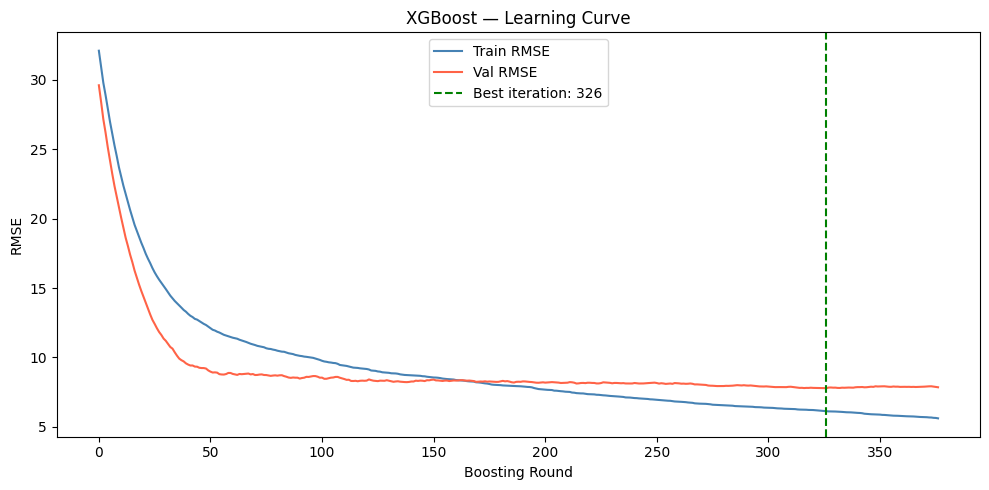

['../models/xgboost_regressor_Outbreak.pkl']

In [ ]:
# XGBoost 
from xgboost import XGBRegressor as xgBoostRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score
import matplotlib.pyplot as plt

featuresXg = [
    "district_encoded", "T2M_mean", "RH2M_mean", "PRECTOTCORR_sum", "WS10M_mean",
    "T2M_lag1", "PRECTOTCORR_lag1", "PRECTOTCORR_lag2",
    "t1_cases", "t2_cases",
    "waterProxy",
    "month_sin", "week_cos", "momentum", "isOutbreak"
]
targetXg = "cases"

xTrainXg = val[featuresXg].copy()
yTrainXg   = val[targetXg].copy()
xValXg   = val[featuresXg].copy()
xTestXg  = test[featuresXg].copy()

# early stopping split — last fold of TimeSeriesSplit
tCsv   = TimeSeriesSplit(n_splits=5)
splits = list(tCsv.split(xTrainXg))
trainIdx, valIdx = splits[-1]

xEarlySplit = xTrainXg.iloc[trainIdx]
yEarlySplit = yTrainXg.iloc[trainIdx]
xValSplit   = xTrainXg.iloc[valIdx]
yValSplit   = yTrainXg.iloc[valIdx]

xgModel = xgBoostRegressor(
    learning_rate=0.05,
    n_estimators=2000,
    max_depth=3,
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_weight=10,
    reg_alpha=0.5,
    reg_lambda=2.0,
    early_stopping_rounds=50,
    eval_metric="rmse",
    random_state=42,
    n_jobs=-1
)

xgModel.fit(
    xEarlySplit, yEarlySplit,
    eval_set=[
        (xEarlySplit, yEarlySplit),
        (xValSplit,   yValSplit)
    ],
    verbose=100
)

print(f"Best iteration: {xgModel.best_iteration}")
print(f"Best val RMSE:  {xgModel.best_score:.4f}")


xgModelCv = xgBoostRegressor(
    learning_rate=0.05,
    n_estimators=xgModel.best_iteration,
    max_depth=3,
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_weight=10,
    reg_alpha=0.5,
    reg_lambda=2.0,
    random_state=42,
    n_jobs=-1
)
xgScores = cross_val_score(xgModelCv, xTrainXg, yTrainXg, cv=tCsv, scoring='r2')
print(f"CV Mean: {xgScores.mean():.4f} ± {xgScores.std():.4f}")

print("\n=== Val 2019 (outbreak) ===")
regressorEvaluation(xgModel, xValXg, yValXg)

print("\n=== Test 2020 (final) ===")
regressorEvaluation(xgModel, xTestXg, yTestXg)


results = xgModel.evals_result()

plt.figure(figsize=(10, 5))
plt.plot(results["validation_0"]["rmse"], label="Train RMSE", color="steelblue")
plt.plot(results["validation_1"]["rmse"], label="Val RMSE",   color="tomato")
plt.axvline(x=xgModel.best_iteration, color="green", linestyle="--",
            label=f"Best iteration: {xgModel.best_iteration}")
plt.xlabel("Boosting Round")
plt.ylabel("RMSE")
plt.title("XGBoost — Learning Curve")
plt.legend()
plt.tight_layout()
plt.show()

jl.dump(xgModel, "../models/xgboost_regressor_Outbreak.pkl")

In [4]:
featuresXg = [
    "district_encoded", "T2M_mean", "RH2M_mean", "PRECTOTCORR_sum", "WS10M_mean",
    "T2M_lag1", "PRECTOTCORR_lag1", "PRECTOTCORR_lag2",
    "t1_cases", "t2_cases",
    "waterProxy",
    "month_sin", "week_cos", "momentum", "isOutbreak"
]
targetXg = "cases"


In [ ]:
import pandas as pd
import joblib as jl
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, mean_absolute_error, r2_score

# Load Models
endemicModel = jl.load("../models/xgboost_regressor.pkl")
outbreakModel = jl.load("../models/xgboost_regressor_outbreak.pkl")

# Configuration
intensityThreshold = 40

def applyFeatureEngineering(targetDf, referenceDf):
    refStats = referenceDf.groupby('district_encoded')['t1_cases'].agg(['mean','std'])
    targetDf['t1_cases_zscore'] = targetDf.apply(
        lambda r: (r['t1_cases'] - refStats.loc[r['district_encoded'], 'mean']) /
                  (refStats.loc[r['district_encoded'], 'std'] + 1e-6), axis=1
    )
    targetDf['cases_acceleration'] = targetDf.groupby('district_encoded')['momentum'].transform(
        lambda x: x - x.shift(1).fillna(0)
    )
    return targetDf

# Prepare Data
clfTrain = pd.concat([train, val], ignore_index=True)
clfTrain = applyFeatureEngineering(clfTrain, clfTrain)
testData = applyFeatureEngineering(test, clfTrain)
valData = applyFeatureEngineering(val, clfTrain)

clfTrain['intensityTarget'] = (clfTrain['cases'] > intensityThreshold).astype(int)

classifierFeatures = [
    "district_encoded", "T2M_mean", "RH2M_mean", "PRECTOTCORR_sum", 
    "waterProxy", "t1_cases", "t2_cases", "momentum", 
    "cases_acceleration", "t1_cases_zscore", "month_sin", "week_cos"
]

magnitudeClassifier = RandomForestClassifier(
    n_estimators=300,
    max_depth=7,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
magnitudeClassifier.fit(clfTrain[classifierFeatures], clfTrain['intensityTarget'])

def evaluateHybridSystem(data, yearLabel):
    # Classification Logic
    outbreakProbs = magnitudeClassifier.predict_proba(data[classifierFeatures])[:, 1]
    yPredClass = (outbreakProbs > 0.7).astype(int)
    yTrueClass = (data['cases'] > intensityThreshold).astype(int)
    
    print(f"\n=== {yearLabel} Classifier Performance ===")
    print(classification_report(yTrueClass, yPredClass, zero_division=0))
    
    print(f"Confusion Matrix {yearLabel}:")
    print(confusion_matrix(yTrueClass, yPredClass))
    
    # Regression Logic
    predEndemic = endemicModel.predict(data[featuresXg])
    predOutbreak = outbreakModel.predict(data[featuresXg])
    
    finalPredictions = []
    for i in range(len(data)):
        if outbreakProbs[i] > 0.7:
            finalPredictions.append(predOutbreak[i])
        else:
            finalPredictions.append(predEndemic[i])
            
    currentMae = mean_absolute_error(data['cases'], finalPredictions)
    currentR2 = r2_score(data['cases'], finalPredictions)
    
    print(f"{yearLabel} Hybrid MAE: {currentMae:.4f}")
    print(f"{yearLabel} Hybrid R²: {currentR2:.4f}")
    
    return finalPredictions

valResults = evaluateHybridSystem(valData, "2019 Val")
testResults = evaluateHybridSystem(testData, "2020 Test")

jl.dump(magnitudeClassifier, "../models/outbreak_classifier.pkl")


=== 2019 Val Classifier Performance ===
              precision    recall  f1-score   support

           0       1.00      0.99      0.99      1490
           1       0.97      0.97      0.97       238

    accuracy                           0.99      1728
   macro avg       0.98      0.98      0.98      1728
weighted avg       0.99      0.99      0.99      1728

Confusion Matrix 2019 Val:
[[1482    8]
 [   7  231]]
2019 Val Hybrid MAE: 3.8199
2019 Val Hybrid R²: 0.9430

=== 2020 Test Classifier Performance ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1728

    accuracy                           1.00      1728
   macro avg       1.00      1.00      1.00      1728
weighted avg       1.00      1.00      1.00      1728

Confusion Matrix 2020 Test:
[[1728]]
2020 Test Hybrid MAE: 0.9306
2020 Test Hybrid R²: 0.8334


c:\Dengue-Outbreak-Predictor\denguePredictor\Lib\site-packages\sklearn\metrics\_classification.py:620: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


['../models/outbreak_classifier.pkl']

In [ ]:
import numpy as np
import pandas as pd
import pickle
import warnings

warnings.filterwarnings("ignore")

from xgboost import XGBClassifier
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    f1_score,
    confusion_matrix,
)
import seaborn as sns
import matplotlib.pyplot as plt

class DynamicBinner:
    """
    Converts raw dengue case counts into severity labels.

        0 -> Low
        1 -> Medium
        2 -> High
        3 -> Severe

    Thresholds are learned from training data only (no leakage).
    Uses log1p transform to handle right-skewed outbreak data.
    """

    LABEL_NAMES = ["Low", "Medium", "High", "Severe"]

    def __init__(
        self,
        percentiles=(30, 75, 92),
        use_log=True,
        remove_outliers=True,
        outlier_percentiles=(1, 99),
        verbose=True,
    ):
        self.percentiles         = percentiles
        self.use_log             = use_log
        self.remove_outliers     = remove_outliers
        self.outlier_percentiles = outlier_percentiles
        self.verbose             = verbose
        self.thresholds_         = None
        self.bins_               = None

    def _preprocess(self, cases: np.ndarray) -> np.ndarray:
        c = np.array(cases, dtype=float).flatten()
        c = c[c >= 0]
        if self.use_log:
            c = np.log1p(c)
        if self.remove_outliers:
            lo, hi = self.outlier_percentiles
            c = c[(c >= np.percentile(c, lo)) & (c <= np.percentile(c, hi))]
        return c

    def fit(self, cases) -> "DynamicBinner":
        c = self._preprocess(np.array(cases, dtype=float).flatten())

        if len(c) < 10:
            raise ValueError(
                f"Only {len(c)} samples after preprocessing. "
                "Check for all-zero or near-constant input."
            )

        p1, p2, p3 = self.percentiles
        thresholds = sorted(np.percentile(c, p) for p in (p1, p2, p3))

        eps = 1e-3
        for i in range(1, len(thresholds)):
            if thresholds[i] <= thresholds[i - 1]:
                thresholds[i] = thresholds[i - 1] + eps

        t1, t2, t3 = thresholds

        if self.use_log:
            t1, t2, t3 = np.expm1(t1), np.expm1(t2), np.expm1(t3)

        t1, t2, t3 = round(float(t1), 2), round(float(t2), 2), round(float(t3), 2)

        if t2 <= t1: t2 = t1 + 0.01
        if t3 <= t2: t3 = t2 + 0.01

        self.thresholds_ = (t1, t2, t3)
        self.bins_       = [-np.inf, t1, t2, t3, np.inf]

        if self.verbose:
            print("\n[DynamicBinner — Learned Thresholds]")
            for lo, hi, name in zip(self.bins_, self.bins_[1:], self.LABEL_NAMES):
                lo_s = f"{lo:.2f}" if np.isfinite(lo) else "-∞"
                hi_s = f"{hi:.2f}" if np.isfinite(hi) else "+∞"
                print(f"  {name:8s}: ({lo_s}, {hi_s}]")

        return self

    def transform(self, cases, print_dist=False) -> np.ndarray:
        if self.bins_ is None:
            raise RuntimeError("Call fit() before transform().")

        labels = pd.cut(
            pd.Series(np.array(cases).flatten()),
            bins=self.bins_,
            labels=[0, 1, 2, 3],
            include_lowest=True,
        ).astype(int).to_numpy()

        if print_dist and self.verbose:
            unique, counts = np.unique(labels, return_counts=True)
            print("\n[DynamicBinner — Class Distribution]")
            for u, c in zip(unique, counts):
                print(f"  {self.LABEL_NAMES[u]:8s}: {c}")

        return labels

    def fit_transform(self, cases, print_dist=True) -> np.ndarray:
        return self.fit(cases).transform(cases, print_dist=print_dist)

    def save(self, path: str) -> None:
        with open(path, "wb") as f:
            pickle.dump(self, f)
        if self.verbose:
            print(f"[DynamicBinner] Saved -> {path}")

    @staticmethod
    def load(path: str) -> "DynamicBinner":
        with open(path, "rb") as f:
            return pickle.load(f)


LABEL_NAMES = DynamicBinner.LABEL_NAMES
binner = DynamicBinner(percentiles=(30, 78, 92), use_log=True, remove_outliers=True)

# 3. Create the Target Labels (y) for the Classifier to learn from
y_train = binner.fit_transform(train["cases"])
y_test  = binner.transform(test["cases"])

print("\nCell 1 Complete: Binner is fitted and LABEL_NAMES are defined.")



[DynamicBinner — Learned Thresholds]
  Low     : (-∞, 2.00]
  Medium  : (2.00, 5.00]
  High    : (5.00, 9.00]
  Severe  : (9.00, +∞]

[DynamicBinner — Class Distribution]
  Low     : 2640
  Medium  : 1417
  High    : 612
  Severe  : 443

Cell 1 Complete: Binner is fitted and LABEL_NAMES are defined.


=== Endemic Expert Severity Performance (Test Set) ===
              precision    recall  f1-score   support

         Low       0.98      0.71      0.82       981
      Medium       0.54      0.74      0.63       450
        High       0.55      0.79      0.65       191
      Severe       0.74      0.93      0.82       106

    accuracy                           0.74      1728
   macro avg       0.70      0.79      0.73      1728
weighted avg       0.80      0.74      0.75      1728



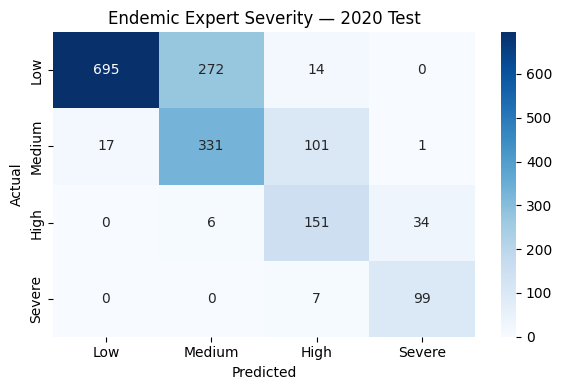

In [ ]:
import joblib as jl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

REGRESSOR_FEATURES = [
    "district_encoded", "T2M_mean", "RH2M_mean", "PRECTOTCORR_sum",
    "WS10M_mean", "T2M_lag1", "PRECTOTCORR_lag1", "PRECTOTCORR_lag2",
    "t1_cases", "t2_cases", "waterProxy", "month_sin", "week_cos",
    "momentum", "isOutbreak"
]

CLASSIFIER_FEATURES = [
    "district_encoded", "T2M_mean", "RH2M_mean", "PRECTOTCORR_sum",
    "waterProxy", "t1_cases", "t2_cases", "momentum",
    "cases_acceleration", "t1_cases_zscore", "month_sin", "week_cos"
]

# Load all three models
endemicRegressor   = jl.load("../models/rf_regressor.pkl")
outbreakRegressor  = jl.load("../models/xgboost_regressor_Outbreak.pkl")
magnitudeClassifier = jl.load("../models/outbreak_classifier.pkl")

testEngineered = applyFeatureEngineering(test, val)

outbreakProbsTest = magnitudeClassifier.predict_proba(testEngineered[CLASSIFIER_FEATURES])[:, 1]
predEndemicTest   = np.clip(endemicRegressor.predict(test[REGRESSOR_FEATURES].fillna(0)),  0, None)
predOutbreakTest  = np.clip(outbreakRegressor.predict(test[REGRESSOR_FEATURES].fillna(0)), 0, None)
predTestHybrid    = np.where(outbreakProbsTest > 0.7, predOutbreakTest, predEndemicTest)

xTestHybrid = pd.DataFrame({"pred_cases": predTestHybrid})
y_test      = binner.transform(test["cases"])

yPredEndemicLabels = binner.transform(predEndemicTest)
yTrueTestLabels    = binner.transform(test["cases"])

print("=== Endemic Expert Severity Performance (Test Set) ===")
print(classification_report(yTrueTestLabels, yPredEndemicLabels,
                             target_names=LABEL_NAMES, zero_division=0))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(yTrueTestLabels, yPredEndemicLabels),
            annot=True, fmt="d", cmap="Blues",
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
plt.title("Endemic Expert Severity — 2020 Test")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

=== Outbreak Expert Severity Performance (Combined Train + Val) ===
              precision    recall  f1-score   support

         Low       0.97      0.33      0.49      3253
      Medium       0.27      0.42      0.33      1741
        High       0.27      0.28      0.27       798
      Severe       0.46      0.95      0.62      1048

    accuracy                           0.44      6840
   macro avg       0.49      0.49      0.43      6840
weighted avg       0.63      0.44      0.44      6840



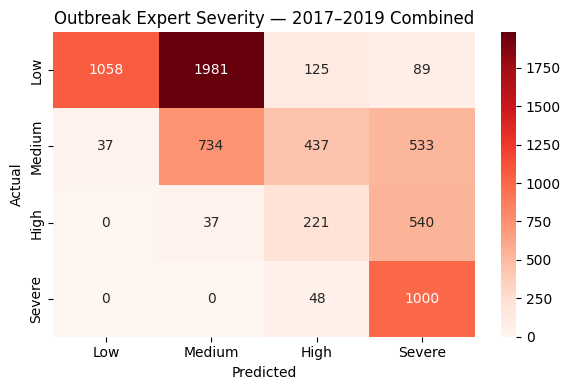


Cell 3 Complete: 6840 training samples ready for severity classifier.


In [ ]:
import joblib as jl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

combined_df = pd.concat([train, val], ignore_index=True)

combinedEngineered = applyFeatureEngineering(combined_df, combined_df)

outbreakProbsTrain = magnitudeClassifier.predict_proba(
    combinedEngineered[CLASSIFIER_FEATURES])[:, 1]
predEndemicTrain  = np.clip(
    endemicRegressor.predict(combinedEngineered[REGRESSOR_FEATURES].fillna(0)),  0, None)
predOutbreakTrain = np.clip(
    outbreakRegressor.predict(combinedEngineered[REGRESSOR_FEATURES].fillna(0)), 0, None)
predTrainHybrid   = np.where(outbreakProbsTrain > 0.7, predOutbreakTrain, predEndemicTrain)

xTrainHybrid   = pd.DataFrame({"pred_cases": predTrainHybrid})
y_train_hybrid = binner.transform(combinedEngineered["cases"])

yPredOutbreakLabels = binner.transform(predOutbreakTrain)

print("=== Outbreak Expert Severity Performance (Combined Train + Val) ===")
print(classification_report(y_train_hybrid, yPredOutbreakLabels,
                             target_names=LABEL_NAMES, zero_division=0))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_train_hybrid, yPredOutbreakLabels),
            annot=True, fmt="d", cmap="Reds",
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
plt.title("Outbreak Expert Severity — 2017–2019 Combined")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

print(f"\nCell 3 Complete: {len(xTrainHybrid)} training samples ready for severity classifier.")

Severity class distribution — classifier train split:
  Low     : 2765
  Medium  : 1480
  High    : 678
  Severe  : 891

Best iteration: 305

==================== SEVERITY CLASSIFIER — 2020 TEST ====================

              precision    recall  f1-score   support

         Low     0.9462    0.8420    0.8910       981
      Medium     0.6764    0.7200    0.6975       450
        High     0.5967    0.7592    0.6682       191
      Severe     0.7444    0.9340    0.8285       106

    accuracy                         0.8067      1728
   macro avg     0.7409    0.8138    0.7713      1728
weighted avg     0.8249    0.8067    0.8122      1728

Accuracy: 0.8067


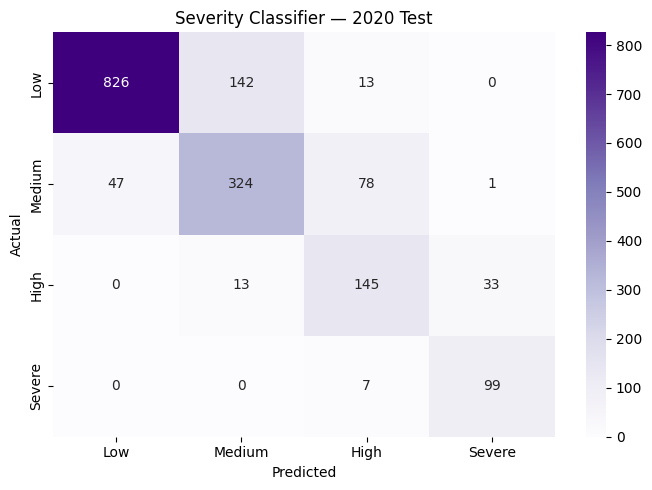

[DynamicBinner] Saved -> ../models/dynamic_binner.pkl

Saved → ../models/dynamic_binner.pkl
Saved → ../models/severity_classifier.pkl


In [ ]:
import pickle
import numpy as np
import joblib as jl
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

xTrClf, xValClf, yTrClf, yValClf = train_test_split(
    xTrainHybrid, y_train_hybrid,
    test_size=0.15,
    random_state=42,
    stratify=y_train_hybrid
)

print("Severity class distribution — classifier train split:")
unique, counts = np.unique(yTrClf, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {LABEL_NAMES[u]:8s}: {c}")

counts      = np.bincount(yTrClf)
weights     = len(yTrClf) / (len(counts) * counts)
sampleWeights = np.array([weights[y] for y in yTrClf])

severityClf = XGBClassifier(
    n_estimators=500,
    max_depth=3,
    learning_rate=0.03,
    objective="multi:softprob",
    num_class=4,
    eval_metric="mlogloss",
    early_stopping_rounds=30,   # now eval_set is actually used for stopping
    random_state=42
)

severityClf.fit(
    xTrClf,
    yTrClf,
    sample_weight=sampleWeights,
    eval_set=[(xValClf, yValClf)],  # internal split only — test remains blind
    verbose=False
)

print(f"\nBest iteration: {severityClf.best_iteration}")

yPredFinal = severityClf.predict(xTestHybrid)

print("\n==================== SEVERITY CLASSIFIER — 2020 TEST ====================\n")
print(classification_report(y_test, yPredFinal, target_names=LABEL_NAMES, digits=4))
print(f"Accuracy: {accuracy_score(y_test, yPredFinal):.4f}")

plt.figure(figsize=(7, 5))
sns.heatmap(
    confusion_matrix(y_test, yPredFinal),
    annot=True, fmt="d", cmap="Purples",
    xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES
)
plt.title("Severity Classifier — 2020 Test")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

binner.save("../models/dynamic_binner.pkl")
jl.dump(severityClf, "../models/severity_classifier.pkl")
print("\nSaved → ../models/dynamic_binner.pkl")
print("Saved → ../models/severity_classifier.pkl")

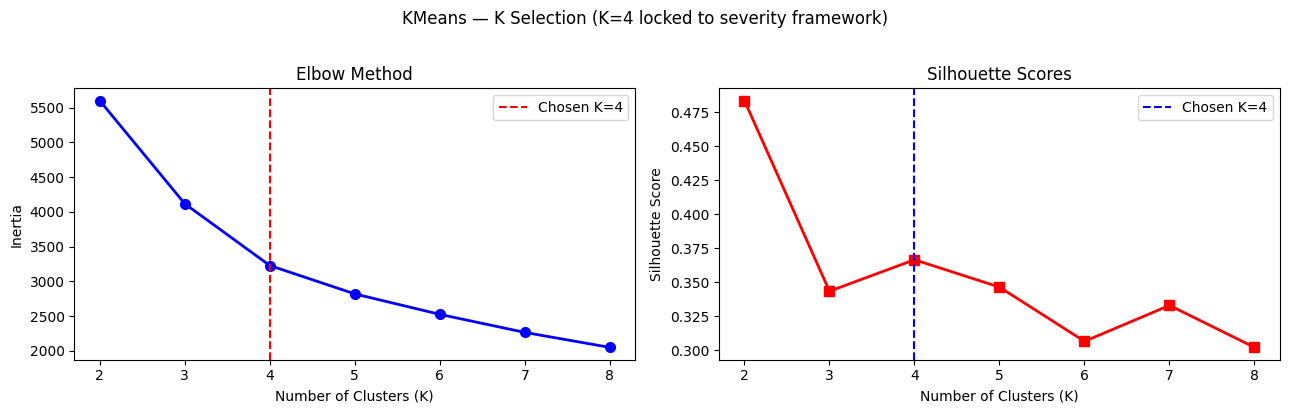

Silhouette-optimal K : 2
Chosen K             : 4  (locked to match DynamicBinner severity levels)
Silhouette at K=4    : 0.3664

Cluster → Risk Zone mapping:
               mean_cases  max_cases  mean_temp  mean_rain  count
risk_zone                                                        
High Risk            9.40      38.32      29.62      46.59    178
Hotspot             28.86      85.04      33.38      14.09    144
Low Risk             2.92      19.09      17.56       7.20    741
Moderate Risk        4.09      19.28      32.38       7.15    665


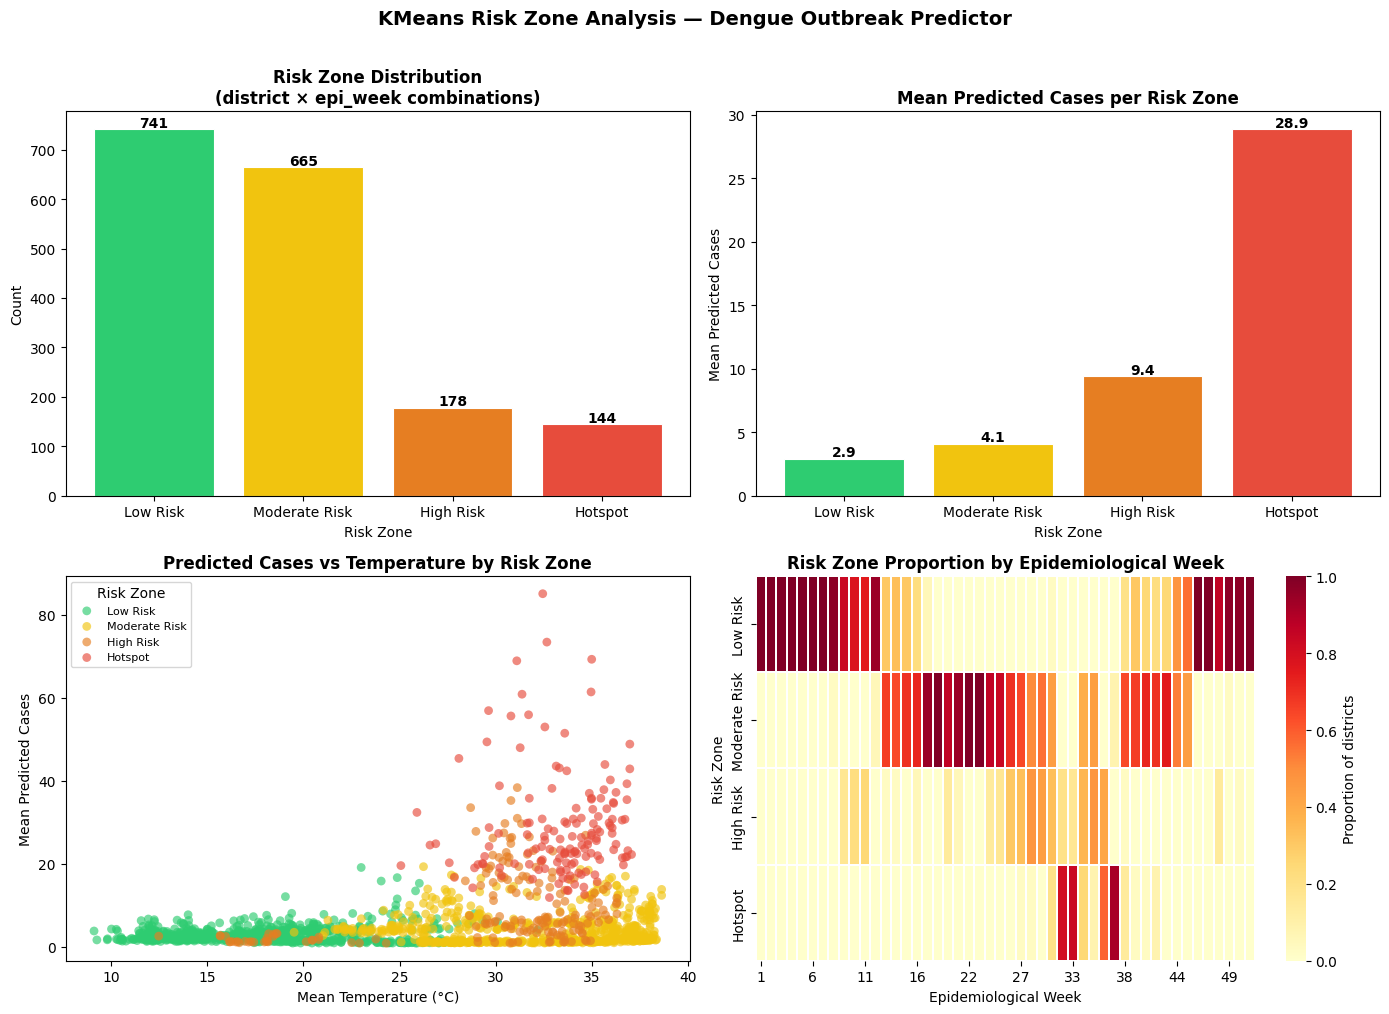

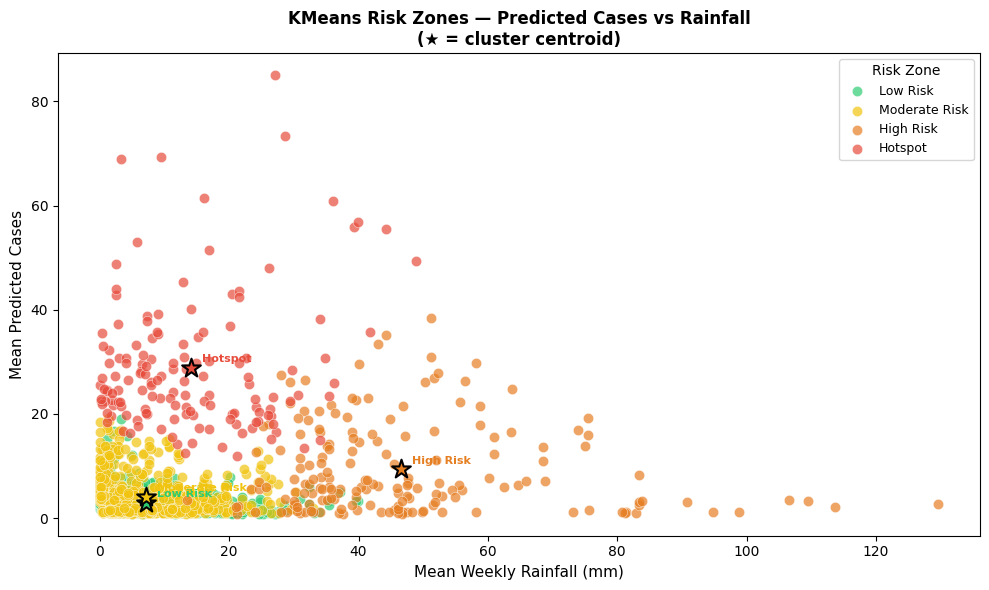


Saved:
  ../models/kmeans_clusters.pkl
  ../models/cluster_scaler.pkl
  ../models/cluster_risk_map.pkl
  ../data/processed/cluster_assignments.csv
  ../reports/figures/kmeans_risk_analysis.png
  ../reports/figures/kmeans_scatter.png

Final cluster assignments:
risk_zone
Low Risk         741
Moderate Risk    665
High Risk        178
Hotspot          144


In [ ]:

import pandas as pd
import numpy as np
import joblib as jl
import pickle
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

train = pd.read_csv("../data/processed/train.csv")
val   = pd.read_csv("../data/processed/val.csv")
test  = pd.read_csv("../data/processed/test.csv")


endemicRegressor    = jl.load("../models/rf_regressor.pkl")
outbreakRegressor   = jl.load("../models/xgboost_regressor_Outbreak.pkl")
magnitudeClassifier = jl.load("../models/outbreak_classifier.pkl")
severityClf         = jl.load("../models/severity_classifier.pkl")
binner              = DynamicBinner.load("../models/dynamic_binner.pkl")

SEVERITY_NAMES = {0: "Low Risk", 1: "Moderate Risk", 2: "High Risk", 3: "Hotspot"}
SEVERITY_COLORS = {
    "Low Risk":      "#2ecc71",
    "Moderate Risk": "#f1c40f",
    "High Risk":     "#e67e22",
    "Hotspot":       "#e74c3c"
}

REGRESSOR_FEATURES = [
    "district_encoded", "T2M_mean", "RH2M_mean", "PRECTOTCORR_sum",
    "WS10M_mean", "T2M_lag1", "PRECTOTCORR_lag1", "PRECTOTCORR_lag2",
    "t1_cases", "t2_cases", "waterProxy",
    "month_sin", "week_cos", "momentum", "isOutbreak"
]

CLASSIFIER_FEATURES = [
    "district_encoded", "T2M_mean", "RH2M_mean", "PRECTOTCORR_sum",
    "waterProxy", "t1_cases", "t2_cases", "momentum",
    "cases_acceleration", "t1_cases_zscore", "month_sin", "week_cos"
]
dfFull = pd.concat([train, val, test], ignore_index=True)

dfFullEngineered = applyFeatureEngineering(dfFull, dfFull)

outbreakProbs = magnitudeClassifier.predict_proba(
    dfFullEngineered[CLASSIFIER_FEATURES])[:, 1]

predEndemic  = np.clip(endemicRegressor.predict(
    dfFullEngineered[REGRESSOR_FEATURES].fillna(0)), 0, None)
predOutbreak = np.clip(outbreakRegressor.predict(
    dfFullEngineered[REGRESSOR_FEATURES].fillna(0)), 0, None)

dfFullEngineered["predicted_cases"] = np.where(
    outbreakProbs > 0.7, predOutbreak, predEndemic)
dfFullEngineered["severity_label"] = severityClf.predict(
    pd.DataFrame({"pred_cases": dfFullEngineered["predicted_cases"]})
)
dfFullEngineered["severity_name"] = dfFullEngineered["severity_label"].map(SEVERITY_NAMES)

clusterInput = dfFullEngineered.groupby(["district_encoded", "epi_week"]).agg(
    mean_predicted  = ("predicted_cases", "mean"),
    mean_temp       = ("T2M_mean",         "mean"),
    mean_humidity   = ("RH2M_mean",        "mean"),
    mean_rainfall   = ("PRECTOTCORR_sum",  "mean"),
    mean_water      = ("waterProxy",       "mean"),
    dominant_severity = ("severity_label", lambda x: x.mode()[0])
).reset_index()

CLUSTER_FEATURES = [
    "mean_predicted", "mean_temp", "mean_humidity",
    "mean_rainfall", "mean_water"
]

clusterScaler = StandardScaler()
xCluster = clusterScaler.fit_transform(clusterInput[CLUSTER_FEATURES])

inertias    = []
silhouettes = []
kRange      = range(2, 9)

for k in kRange:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(xCluster)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(xCluster, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

ax1.plot(list(kRange), inertias, "bo-", linewidth=2, markersize=7)
ax1.axvline(x=4, color="red", linestyle="--", linewidth=1.5, label="Chosen K=4")
ax1.set_xlabel("Number of Clusters (K)")
ax1.set_ylabel("Inertia")
ax1.set_title("Elbow Method")
ax1.legend()

ax2.plot(list(kRange), silhouettes, "rs-", linewidth=2, markersize=7)
ax2.axvline(x=4, color="blue", linestyle="--", linewidth=1.5, label="Chosen K=4")
ax2.set_xlabel("Number of Clusters (K)")
ax2.set_ylabel("Silhouette Score")
ax2.set_title("Silhouette Scores")
ax2.legend()

plt.suptitle("KMeans — K Selection (K=4 locked to severity framework)", 
             fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

silhouetteOptimal = list(kRange)[int(np.argmax(silhouettes))]
print(f"Silhouette-optimal K : {silhouetteOptimal}")
print(f"Chosen K             : 4  (locked to match DynamicBinner severity levels)")
print(f"Silhouette at K=4    : {silhouettes[list(kRange).index(4)]:.4f}")

kMeans = KMeans(n_clusters=4, random_state=42, n_init=10)
clusterInput["cluster"] = kMeans.fit_predict(xCluster)
clusterSeverityMap = (
    clusterInput.groupby("cluster")["dominant_severity"]
    .agg(lambda x: x.mode()[0])
)

clusterMeanCases = clusterInput.groupby("cluster")["mean_predicted"].mean()

usedLabels   = {}
clusterToRisk = {}

for cluster in sorted(clusterMeanCases.index, key=lambda c: clusterMeanCases[c]):
    severityVote = clusterSeverityMap[cluster]
    if severityVote in usedLabels.values():
        severityVote = min(severityVote + 1, 3)
    clusterToRisk[cluster]      = SEVERITY_NAMES[severityVote]
    usedLabels[cluster]         = severityVote

clusterInput["risk_zone"] = clusterInput["cluster"].map(clusterToRisk)

print("\nCluster → Risk Zone mapping:")
summary = clusterInput.groupby("risk_zone").agg(
    mean_cases  = ("mean_predicted", "mean"),
    max_cases   = ("mean_predicted", "max"),
    mean_temp   = ("mean_temp",      "mean"),
    mean_rain   = ("mean_rainfall",  "mean"),
    count       = ("mean_predicted", "count")
).round(2)
print(summary.to_string())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("KMeans Risk Zone Analysis — Dengue Outbreak Predictor", 
             fontsize=14, fontweight="bold", y=1.01)

riskOrder  = ["Low Risk", "Moderate Risk", "High Risk", "Hotspot"]
riskCounts = clusterInput["risk_zone"].value_counts().reindex(riskOrder).fillna(0)
barColors  = [SEVERITY_COLORS[r] for r in riskOrder]

axes[0, 0].bar(riskOrder, riskCounts.values, color=barColors, edgecolor="white", linewidth=0.8)
axes[0, 0].set_title("Risk Zone Distribution\n(district × epi_week combinations)", fontweight="bold")
axes[0, 0].set_ylabel("Count")
axes[0, 0].set_xlabel("Risk Zone")
for i, (zone, count) in enumerate(zip(riskOrder, riskCounts.values)):
    axes[0, 0].text(i, count + 5, str(int(count)), ha="center", fontsize=10, fontweight="bold")

zoneMeans = clusterInput.groupby("risk_zone")["mean_predicted"].mean().reindex(riskOrder)
axes[0, 1].bar(riskOrder, zoneMeans.values, color=barColors, edgecolor="white", linewidth=0.8)
axes[0, 1].set_title("Mean Predicted Cases per Risk Zone", fontweight="bold")
axes[0, 1].set_ylabel("Mean Predicted Cases")
axes[0, 1].set_xlabel("Risk Zone")
for i, (zone, val) in enumerate(zip(riskOrder, zoneMeans.values)):
    axes[0, 1].text(i, val + 0.2, f"{val:.1f}", ha="center", fontsize=10, fontweight="bold")

for zone in riskOrder:
    subset = clusterInput[clusterInput["risk_zone"] == zone]
    axes[1, 0].scatter(
        subset["mean_temp"], subset["mean_predicted"],
        c=SEVERITY_COLORS[zone], label=zone,
        alpha=0.65, s=40, edgecolors="none"
    )
axes[1, 0].set_title("Predicted Cases vs Temperature by Risk Zone", fontweight="bold")
axes[1, 0].set_xlabel("Mean Temperature (°C)")
axes[1, 0].set_ylabel("Mean Predicted Cases")
axes[1, 0].legend(title="Risk Zone", fontsize=8)
weekRiskPivot = pd.crosstab(
    clusterInput["epi_week"],
    clusterInput["risk_zone"]
)[riskOrder]

weekRiskNorm = weekRiskPivot.div(weekRiskPivot.sum(axis=1), axis=0)

sns.heatmap(
    weekRiskNorm.T,
    ax=axes[1, 1],
    cmap="YlOrRd",
    linewidths=0.3,
    linecolor="white",
    cbar_kws={"label": "Proportion of districts"},
    xticklabels=5
)
axes[1, 1].set_title("Risk Zone Proportion by Epidemiological Week", fontweight="bold")
axes[1, 1].set_xlabel("Epidemiological Week")
axes[1, 1].set_ylabel("Risk Zone")

plt.tight_layout()

plt.show()

fig, ax = plt.subplots(figsize=(10, 6))

for zone in riskOrder:
    subset = clusterInput[clusterInput["risk_zone"] == zone]
    ax.scatter(
        subset["mean_rainfall"], subset["mean_predicted"],
        c=SEVERITY_COLORS[zone], label=zone,
        alpha=0.7, s=55, edgecolors="white", linewidths=0.4
    )


for cluster, zone in clusterToRisk.items():
    centroidScaled = kMeans.cluster_centers_[cluster]
    centroidOrig = clusterScaler.inverse_transform(
        centroidScaled.reshape(1, -1))[0]
    ax.scatter(centroidOrig[3], centroidOrig[0],
               c=SEVERITY_COLORS[zone], s=200,
               edgecolors="black", linewidths=1.5, zorder=5, marker="*")
    ax.annotate(zone, (centroidOrig[3], centroidOrig[0]),
                textcoords="offset points", xytext=(8, 4),
                fontsize=8, fontweight="bold",
                color=SEVERITY_COLORS[zone])

ax.set_xlabel("Mean Weekly Rainfall (mm)", fontsize=11)
ax.set_ylabel("Mean Predicted Cases", fontsize=11)
ax.set_title("KMeans Risk Zones — Predicted Cases vs Rainfall\n(★ = cluster centroid)",
             fontsize=12, fontweight="bold")
ax.legend(title="Risk Zone", fontsize=9)
plt.tight_layout()

plt.show()

jl.dump(kMeans,        "../models/kmeans_clusters.pkl")
jl.dump(clusterScaler, "../models/cluster_scaler.pkl")
clusterInput.to_csv("../data/processed/cluster_assignments.csv", index=False)

with open("../models/cluster_risk_map.pkl", "wb") as f:
    pickle.dump(clusterToRisk, f)

print("\nSaved:")
print("  ../models/kmeans_clusters.pkl")
print("  ../models/cluster_scaler.pkl")
print("  ../models/cluster_risk_map.pkl")
print("  ../data/processed/cluster_assignments.csv")
print("  ../reports/figures/kmeans_risk_analysis.png")
print("  ../reports/figures/kmeans_scatter.png")
print(f"\nFinal cluster assignments:")
print(clusterInput["risk_zone"].value_counts().reindex(riskOrder).to_string())